# 폴드별 점수 분산 확인 v2 (seed 변경 버전)

## 개선사항
```
feats_top250.parquet 바로 로드
→ LGB Feature Selection 생략!
→ 시간 절약!

seed 3개로 분산 안정성 확인
→ 42, 0, 123
```


## 셀 1: 환경 설정

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd, numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

FEAT_DIR = '/content/drive/MyDrive/머신러닝 기말'
DATA_DIR = '/content/drive/MyDrive/머신러닝 기말'
print('환경 설정 완료')

Mounted at /content/drive
환경 설정 완료


## 셀 2: 데이터 로딩

In [2]:
y_train   = pd.read_csv(f'{DATA_DIR}/y_train.csv')
train_ids = y_train['custid'].values

f1 = pd.read_parquet(f'{FEAT_DIR}/feats_1st.parquet')
f1_train = f1.loc[train_ids]
f1_test  = f1.loc[f1.index.difference(train_ids)]
test_ids = f1_test.index.values

f2        = pd.read_parquet(f'{FEAT_DIR}/tx_stack_v3.parquet')
f2_train  = f2.loc[train_ids]

ex_tr  = pd.read_parquet(f'{FEAT_DIR}/extra_features_train.parquet')
tm_tr  = pd.read_parquet(f'{FEAT_DIR}/timing_train.parquet')

extra  = pd.concat([ex_tr,
         pd.read_parquet(f'{FEAT_DIR}/extra_features_test.parquet')])
extra.columns = ['ex_'+c for c in extra.columns]
timing = pd.concat([tm_tr,
         pd.read_parquet(f'{FEAT_DIR}/timing_test.parquet')])

X = (f1.join(f2).join(extra).join(timing))
X.columns = [str(c) for c in X.columns]
X = X.loc[:, ~X.columns.duplicated()].fillna(0)

t   = y_train.set_index('custid')['gender'].loc[train_ids].values
Xtr = X.loc[train_ids].values.astype(np.float32)

print(f'전체 피처: {X.shape[1]}개')
print(f'train: {len(train_ids)}명')

전체 피처: 523개
train: 30000명


## 셀 3: ranked 로드
feats_top250.parquet에서 바로 로드 → LGB 생략!

In [3]:
# LGB Feature Selection 생략!
# 이성진이 저장한 top250 순서 그대로 사용
feats_250 = pd.read_parquet(f'{FEAT_DIR}/feats_top250.parquet')
ranked    = list(feats_250.columns)
print(f'ranked 로드 완료: {len(ranked)}개')
print(f'상위 10개: {ranked[:10]}')

ranked 로드 완료: 250개
상위 10개: ['txp_mean', 'txp_median', 'txp_amtw', 'txp_q25', 'te_brd_nm_gender', 'txp_ax_fem_mean', 't_wday_evening_r', 'st_disc_std', 'ex_te_buyer_nm_mean', 'int_ratio_남성']


## 셀 4: 폴드별 분산 확인 (seed 3개)

In [4]:
def check_fold_variance(Xtr, t, top_n, n_splits=5, seed=42):
    sel   = ranked[:top_n]
    X_sel = X.loc[train_ids][sel].values.astype(np.float32)

    skf  = StratifiedKFold(n_splits=n_splits,
                            shuffle=True, random_state=seed)
    fold_scores = []

    for fold, (tr, val) in enumerate(skf.split(X_sel, t), 1):
        m = lgb.LGBMClassifier(
            n_estimators=300, learning_rate=0.04,
            num_leaves=31, subsample=0.8,
            colsample_bytree=0.55, reg_lambda=2.0,
            n_jobs=-1, max_bin=127, verbose=-1,
            random_state=seed)
        m.fit(X_sel[tr], t[tr])
        score = roc_auc_score(
            t[val], m.predict_proba(X_sel[val])[:,1])
        fold_scores.append(score)

    mean = np.mean(fold_scores)
    std  = np.std(fold_scores)
    rng  = max(fold_scores) - min(fold_scores)
    return fold_scores, mean, std, rng

all_seed_results = {}

for seed in [42, 0, 123]:
    print()
    print("=" * 55)
    print(f"🌱 random_state = {seed}")
    print("=" * 55)

    seed_results = {}
    for TOP in [250, 300]:
        scores, mean, std, rng = check_fold_variance(
            Xtr, t, TOP, seed=seed)
        seed_results[TOP] = scores

        print(f"TOP {TOP}:")
        for i, s in enumerate(scores, 1):
            print(f"  Fold {i}: {s:.5f}")
        print(f"  평균: {mean:.5f} | 표준편차: {std:.5f} | 범위: {rng:.5f}")
        if std < 0.005:
            print("  → ✅ 안정적!")
        elif std < 0.010:
            print("  → ⚠️ 보통")
        else:
            print("  → ❌ 분산 큼!")

    all_seed_results[seed] = seed_results

print()
print("=" * 55)
print("📊 seed별 표준편차 비교")
print("=" * 55)
for seed in [42, 0, 123]:
    for TOP in [250, 300]:
        scores = all_seed_results[seed][TOP]
        std    = np.std(scores)
        print(f"  seed={seed} TOP{TOP}: 표준편차={std:.5f}")


🌱 random_state = 42
TOP 250:
  Fold 1: 0.71861
  Fold 2: 0.71444
  Fold 3: 0.72177
  Fold 4: 0.71158
  Fold 5: 0.73755
  평균: 0.72079 | 표준편차: 0.00908 | 범위: 0.02597
  → ⚠️ 보통
TOP 300:
  Fold 1: 0.71861
  Fold 2: 0.71444
  Fold 3: 0.72177
  Fold 4: 0.71158
  Fold 5: 0.73755
  평균: 0.72079 | 표준편차: 0.00908 | 범위: 0.02597
  → ⚠️ 보통

🌱 random_state = 0
TOP 250:
  Fold 1: 0.73071
  Fold 2: 0.71456
  Fold 3: 0.72114
  Fold 4: 0.72482
  Fold 5: 0.71794
  평균: 0.72184 | 표준편차: 0.00559 | 범위: 0.01615
  → ⚠️ 보통
TOP 300:
  Fold 1: 0.73071
  Fold 2: 0.71456
  Fold 3: 0.72114
  Fold 4: 0.72482
  Fold 5: 0.71794
  평균: 0.72184 | 표준편차: 0.00559 | 범위: 0.01615
  → ⚠️ 보통

🌱 random_state = 123
TOP 250:
  Fold 1: 0.72570
  Fold 2: 0.72251
  Fold 3: 0.72567
  Fold 4: 0.72719
  Fold 5: 0.70165
  평균: 0.72055 | 표준편차: 0.00957 | 범위: 0.02553
  → ⚠️ 보통
TOP 300:
  Fold 1: 0.72570
  Fold 2: 0.72251
  Fold 3: 0.72567
  Fold 4: 0.72719
  Fold 5: 0.70165
  평균: 0.72055 | 표준편차: 0.00957 | 범위: 0.02553
  → ⚠️ 보통

📊 seed별 표준편차 비교
  

## 셀 5: 시각화

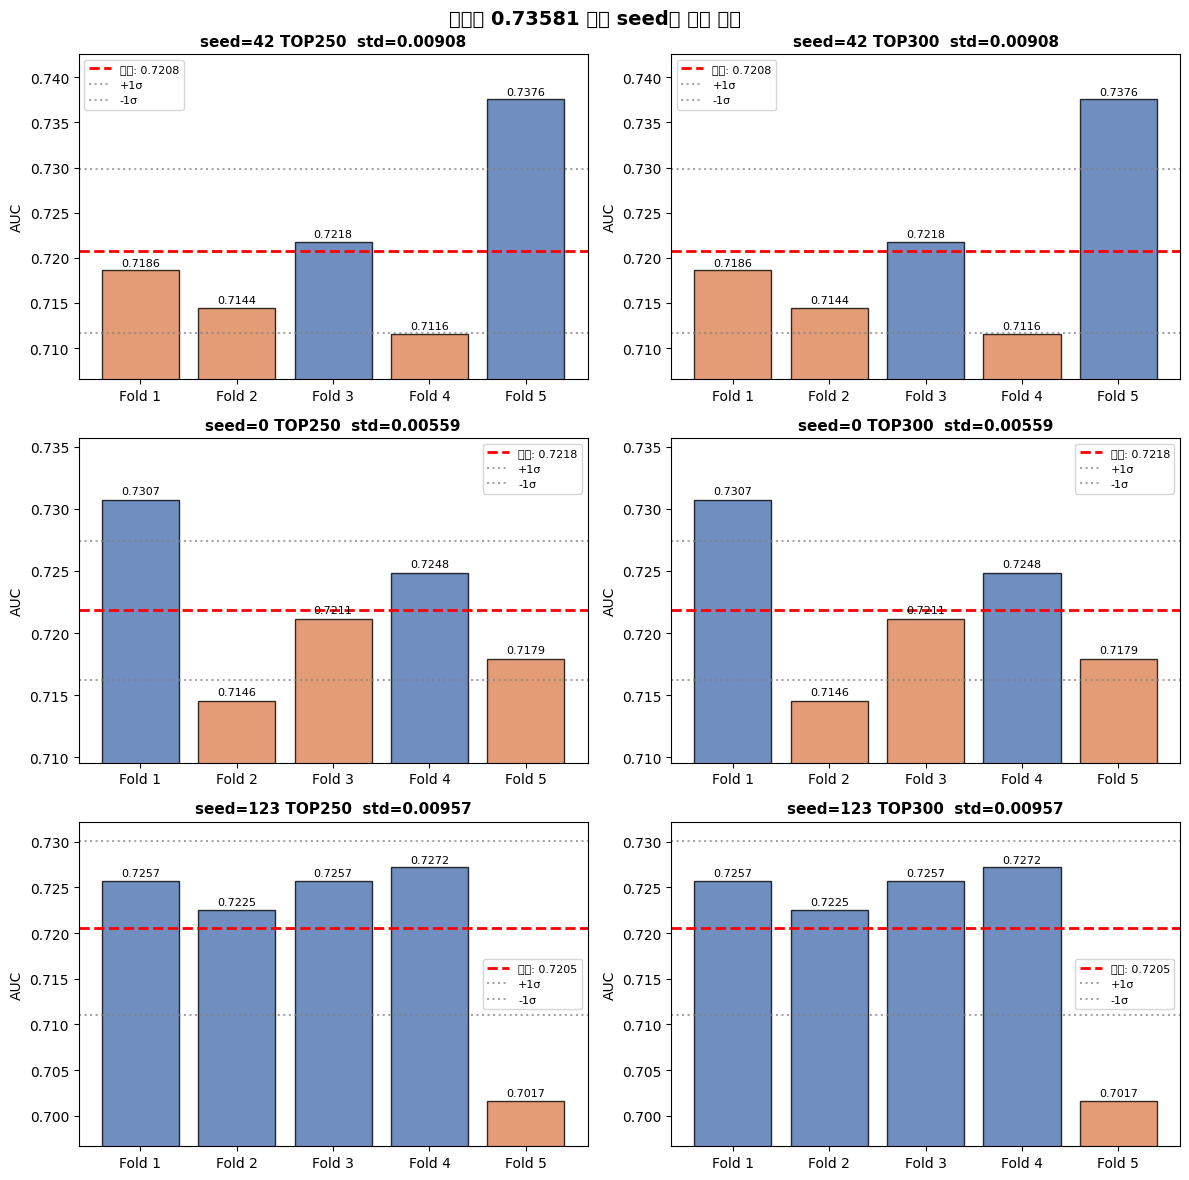

✅ 시각화 저장: fold_variance_seeds.png


In [6]:
fig, axes = plt.subplots(3, 2, figsize=(12, 12))

for row, seed in enumerate([42, 0, 123]):
    for col, TOP in enumerate([250, 300]):
        ax     = axes[row][col]
        scores = all_seed_results[seed][TOP]
        folds  = [f'Fold {i}' for i in range(1, 6)]
        mean   = np.mean(scores)
        std    = np.std(scores)

        bars = ax.bar(folds, scores,
                      color=['#4C72B0' if s >= mean else '#DD8452'
                             for s in scores],
                      alpha=0.8, edgecolor='black')

        ax.axhline(mean, color='red', linestyle='--',
                   linewidth=2, label=f'평균: {mean:.4f}')
        ax.axhline(mean+std, color='gray', linestyle=':',
                   alpha=0.7, label='+1σ')
        ax.axhline(mean-std, color='gray', linestyle=':',
                   alpha=0.7, label='-1σ')

        title = f'seed={seed} TOP{TOP}  std={std:.5f}'
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_ylabel('AUC')
        ax.set_ylim(min(scores)-0.005, max(scores)+0.005)
        ax.legend(fontsize=8)

        for bar, score in zip(bars, scores):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.0003,
                    f'{score:.4f}', ha='center',
                    va='bottom', fontsize=8)

plt.suptitle('이성진 0.73581 기준 seed별 폴드 분산',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FEAT_DIR}/fold_variance_seeds.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ 시각화 저장: fold_variance_seeds.png")

## 셀 6: 팀원 공유용 결과

In [7]:
print("=" * 55)
print("📢 팀원 공유용 결과 (seed 3개 평균)")
print("=" * 55)
print("기준: 이성진 0.73581 (top250) feature 조합")
print("모델: LightGBM 5-Fold (StratifiedKFold)")
print()

for TOP in [250, 300]:
    all_stds = []
    print(f"TOP {TOP}:")
    for seed in [42, 0, 123]:
        scores = all_seed_results[seed][TOP]
        std    = np.std(scores)
        mean   = np.mean(scores)
        all_stds.append(std)
        print(f"  seed={seed}: 평균={mean:.5f} 표준편차={std:.5f}")
    print(f"  평균 표준편차: {np.mean(all_stds):.5f}")
    print()

print("결론:")
std250 = np.mean([np.std(all_seed_results[s][250]) for s in [42,0,123]])
std300 = np.mean([np.std(all_seed_results[s][300]) for s in [42,0,123]])
if std250 < std300:
    print(f"  top250이 더 안정적! (표준편차 {std250:.5f} < {std300:.5f})")
else:
    print(f"  top300이 더 안정적! (표준편차 {std300:.5f} < {std250:.5f})")

print()
print("Fold 5 패턴:")
for seed in [42, 0, 123]:
    scores = all_seed_results[seed][250]
    max_fold = scores.index(max(scores)) + 1
    print(f"  seed={seed}: 가장 높은 Fold = Fold {max_fold} ({max(scores):.5f})")

📢 팀원 공유용 결과 (seed 3개 평균)
기준: 이성진 0.73581 (top250) feature 조합
모델: LightGBM 5-Fold (StratifiedKFold)

TOP 250:
  seed=42: 평균=0.72079 표준편차=0.00908
  seed=0: 평균=0.72184 표준편차=0.00559
  seed=123: 평균=0.72055 표준편차=0.00957
  평균 표준편차: 0.00808

TOP 300:
  seed=42: 평균=0.72079 표준편차=0.00908
  seed=0: 평균=0.72184 표준편차=0.00559
  seed=123: 평균=0.72055 표준편차=0.00957
  평균 표준편차: 0.00808

결론:
  top300이 더 안정적! (표준편차 0.00808 < 0.00808)

Fold 5 패턴:
  seed=42: 가장 높은 Fold = Fold 5 (0.73755)
  seed=0: 가장 높은 Fold = Fold 1 (0.73071)
  seed=123: 가장 높은 Fold = Fold 4 (0.72719)
